# Research Intake 2026 — Day 31
# Object Detection Fundamentals

**Module:** Computer Vision Fundamentals
**Source:** Gudsky Research Foundation — Research Intake 2026, Day 31

This notebook accompanies the Day 31 reading in full detail: the geometry and evaluation machinery
underlying every detector (IoU, mAP), the two-stage R-CNN lineage, the one-stage YOLO/SSD lineage,
anchor boxes and NMS, and closes with the full **graded practical project, PP11** (fine-tune both a
YOLO model and an SSD model on the same dataset and compare them rigorously).

**How to use this notebook:** Sections 1–10 build every concept from first principles with runnable
code — a from-scratch IoU function, a from-scratch NMS implementation, a from-scratch mAP calculation
matching the reading's worked example, and a minimal from-scratch YOLO-style single-shot detection
head, so the mechanics are visible rather than hidden behind a library call. Section "PP11" then
assembles a genuine, working two-detector fine-tuning and comparison pipeline using `torchvision`'s
built-in SSD implementation and (optionally) the `ultralytics` YOLO implementation, following the
reading's Section 8.3 fair-comparison methodology exactly.


## 0. Environment Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    print("PyTorch version:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
except ImportError:
    print("PyTorch not installed — install with: pip install torch")

try:
    import torchvision
    import torchvision.models as models
    import torchvision.models.detection as detection_models
    print("torchvision version:", torchvision.__version__)
except ImportError:
    print("torchvision not installed — install with: pip install torchvision")

torch.manual_seed(0)
np.random.seed(0)


PyTorch version: 2.11.0+cu128
CUDA available: True
torchvision version: 0.26.0+cu128


## 1. From Classification to Detection

Day 26 §4 introduced the task taxonomy — this day picks up the "detection" row directly: identifying
every object of interest in an image and reporting both *what* it is and *where* it is, for
potentially many objects simultaneously.

### 1.1 Why detection is harder than classification
Classification assumes a single label describes the entire image. Detection removes that assumption
along three axes: the **number of objects** isn't known in advance; the **location** of each isn't
known in advance; and **class and location must be predicted jointly, per object**.

| Property | Classification (Day 29) | Object Detection (this day) |
|---|---|---|
| Output structure | One label per image | A variable-length list of (box, label, score) triples |
| Number of objects | Assumed to be exactly one | Unknown in advance; zero, one, or many |
| Spatial information | None | A bounding box per detected object |
| Typical loss function | Cross-entropy (Day 29 §7.2) | A combined localization + classification loss |
| Evaluation metric | Accuracy / top-k accuracy | mAP (§3) |

### 1.2 Detection = backbone + detection head
Every detector this day covers follows the same structural pattern: a **backbone** extracts features
(Day 30's entire survey applies directly here), and a task-specific **detection head** transforms
those features into predicted boxes and classes. What differs between detectors is entirely the head.

**Worked Example: backbone vs. head — where the parameters actually live.** A typical Faster R-CNN
with a ResNet-50 backbone has ~41M total parameters — ~23M in the backbone alone, ~18M split between
the RPN and the final head. This ~55/45 split is a useful sanity check: swapping in a more efficient
backbone (Day 30 §6) reduces the larger component; head-specific optimizations address the smaller
remaining share — but backbone choice is usually the higher-leverage decision.

### 1.3 This day's practical project — PP11
This day carries a **graded assignment**, developed in full at the end of this notebook. Unlike the
theory-only days around it, PP11 requires fine-tuning *both* a YOLO model and an SSD model on the same
dataset and directly comparing them — making Sections 5, 6, and 8 directly load-bearing.

### 1.4 A note on terminology
**Localization** = single-object case (predict one box + class, given exactly one object present).
**Detection** = the multi-object generalization (this day's subject). **Recognition** is a broader,
less precisely defined term sometimes used loosely for classification/detection collectively.


## 2. Bounding Boxes & Localization

### 2.1 Bounding box representations
**xyxy**: (x_min, y_min, x_max, y_max) — corner coordinates. **xywh**: (x_center, y_center, width,
height) — center point + dimensions. Both describe the same rectangle and convert losslessly, but
different frameworks default to different formats — YOLO's native label format uses normalized xywh;
many general-purpose datasets/libraries default to xyxy. Mixing formats without explicit, correct
conversion is a common, silent bug.


In [2]:
# Bounding box format conversions (§2.1) -- the foundation every downstream computation builds on
def xyxy_to_xywh(box):
    x_min, y_min, x_max, y_max = box
    w, h = x_max - x_min, y_max - y_min
    return (x_min + w / 2, y_min + h / 2, w, h)

def xywh_to_xyxy(box):
    xc, yc, w, h = box
    return (xc - w / 2, yc - h / 2, xc + w / 2, yc + h / 2)

sample_box_xyxy = (10, 20, 60, 80)
converted = xyxy_to_xywh(sample_box_xyxy)
round_trip = xywh_to_xyxy(converted)

print(f"Original (xyxy): {sample_box_xyxy}")
print(f"Converted (xywh): {converted}")
print(f"Round-trip back to xyxy: {round_trip}")
assert sample_box_xyxy == round_trip, "Round-trip conversion should be lossless"
print("Round-trip conversion verified lossless.")


Original (xyxy): (10, 20, 60, 80)
Converted (xywh): (35.0, 50.0, 50, 60)
Round-trip back to xyxy: (10.0, 20.0, 60.0, 80.0)
Round-trip conversion verified lossless.


### 2.2 Ground truth annotation formats
- **COCO** — single JSON file, boxes in (x_min, y_min, width, height) — a specific hybrid, neither
  pure xyxy nor pure xywh.
- **Pascal VOC** — one XML file per image, boxes in xyxy.
- **YOLO** — one plain-text file per image, one line per object, normalized xywh.

**Critical detail:** when an image is resized during preprocessing, bounding box coordinates must be
rescaled by the *identical* factor applied to the image — a box recorded relative to a 1920×1080
original is wrong if applied unchanged to a 640×360 resized version.


In [3]:
# COCO's specific hybrid box format, and the resize-rescaling pitfall (§2.2)
def coco_to_xyxy(coco_box):
    x_min, y_min, w, h = coco_box
    return (x_min, y_min, x_min + w, y_min + h)

coco_box = (100, 150, 80, 60)  # (x_min, y_min, width, height)
print("COCO format box:", coco_box)
print("Converted to xyxy:", coco_to_xyxy(coco_box))

def rescale_box_for_resize(box_xyxy, original_size, new_size):
    orig_w, orig_h = original_size
    new_w, new_h = new_size
    scale_x, scale_y = new_w / orig_w, new_h / orig_h
    x1, y1, x2, y2 = box_xyxy
    return (x1 * scale_x, y1 * scale_y, x2 * scale_x, y2 * scale_y)

original_box = (200, 300, 800, 700)
rescaled = rescale_box_for_resize(original_box, original_size=(1920, 1080), new_size=(640, 360))
print(f"\nOriginal box on 1920x1080 image: {original_box}")
print(f"Correctly rescaled for 640x360 resize: {tuple(round(v, 1) for v in rescaled)}")


COCO format box: (100, 150, 80, 60)
Converted to xyxy: (100, 150, 180, 210)

Original box on 1920x1080 image: (200, 300, 800, 700)
Correctly rescaled for 640x360 resize: (66.7, 100.0, 266.7, 233.3)


### 2.3 Intersection over Union — the core geometric primitive
IoU measures how well two boxes overlap: intersection area divided by union area, on a scale from 0
(no overlap) to 1 (perfect overlap). Everything else in this day — evaluation (§3), anchor matching
(§7), and NMS (§7) — builds directly on this primitive.


In [4]:
def compute_iou(box_a, box_b):
    # boxes in xyxy format (§2.1): (x_min, y_min, x_max, y_max)
    x1 = max(box_a[0], box_b[0])
    y1 = max(box_a[1], box_b[1])
    x2 = min(box_a[2], box_b[2])
    y2 = min(box_a[3], box_b[3])
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])
    union = area_a + area_b - intersection
    return intersection / union if union > 0 else 0.0

# Worked Example: computing IoU by hand (mirrors the reading's worked example)
gt_box = (2, 2, 7, 7)       # 5x5 square, area 25
pred_box = (4, 3, 9, 8)     # 5x5 square, area 25

iou = compute_iou(gt_box, pred_box)
print(f"Ground truth box: {gt_box}")
print(f"Predicted box: {pred_box}")
print(f"IoU: {iou:.3f}")
print(f"Counted as a correct match at IoU >= 0.5 threshold? {iou >= 0.5}")


Ground truth box: (2, 2, 7, 7)
Predicted box: (4, 3, 9, 8)
IoU: 0.316
Counted as a correct match at IoU >= 0.5 threshold? False


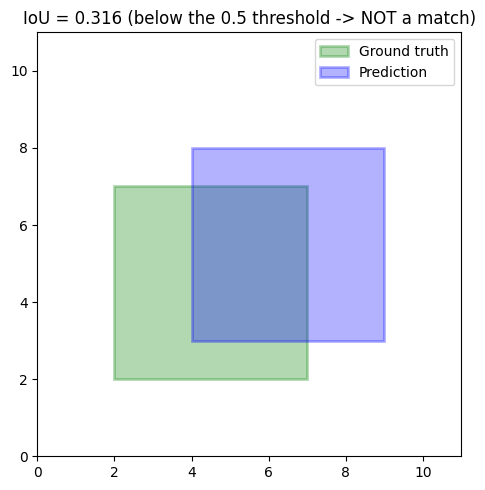

In [5]:
# Visualize the IoU worked example directly
fig, ax = plt.subplots(figsize=(5, 5))
gt_rect = patches.Rectangle((gt_box[0], gt_box[1]), gt_box[2]-gt_box[0], gt_box[3]-gt_box[1],
                             linewidth=2, edgecolor="green", facecolor="green", alpha=0.3, label="Ground truth")
pred_rect = patches.Rectangle((pred_box[0], pred_box[1]), pred_box[2]-pred_box[0], pred_box[3]-pred_box[1],
                               linewidth=2, edgecolor="blue", facecolor="blue", alpha=0.3, label="Prediction")
ax.add_patch(gt_rect)
ax.add_patch(pred_rect)
ax.set_xlim(0, 11); ax.set_ylim(0, 11)
ax.set_title(f"IoU = {iou:.3f} (below the 0.5 threshold -> NOT a match)")
ax.legend(); ax.set_aspect("equal")
plt.tight_layout(); plt.show()


## 3. Detection Evaluation Metrics

### 3.1 Precision and recall at an IoU threshold
A detection is a **true positive** only if the predicted class matches ground truth AND IoU exceeds a
threshold (conventionally 0.5). **Precision** = fraction of predictions that were correct. **Recall**
= fraction of ground-truth objects that were successfully detected.

| Outcome | Condition | Contributes To |
|---|---|---|
| True Positive (TP) | Correct class AND IoU ≥ threshold | Precision (numerator) and Recall (numerator) |
| False Positive (FP) | Prediction with no matching ground truth (wrong class or IoU too low) | Precision (denominator only) |
| False Negative (FN) | A ground-truth object with no matching prediction at all | Recall (denominator only) |

**Worked Example: classification error vs. localization error.** A detector predicts a box with 0.9
confidence, correctly classified "dog," but IoU only 0.3 against the true box — this is a **FALSE
POSITIVE** despite the correct class label, since IoU 0.3 falls below the 0.5 threshold. Distinguishing
these two failure modes (visualizing predicted boxes directly, per §11) matters for interpreting PP11's
own results.


In [6]:
def classify_prediction(pred_class, gt_class, pred_box, gt_box, iou_threshold=0.5):
    iou = compute_iou(pred_box, gt_box)
    if pred_class == gt_class and iou >= iou_threshold:
        return "True Positive", iou
    elif pred_class == gt_class and iou < iou_threshold:
        return "False Positive (localization error)", iou
    else:
        return "False Positive (classification error)", iou

result, iou_val = classify_prediction("dog", "dog", pred_box=(4, 3, 9, 8), gt_box=(2, 2, 7, 7))
print(f"Prediction: correct class 'dog', IoU={iou_val:.3f} -> {result}")


Prediction: correct class 'dog', IoU=0.316 -> False Positive (localization error)


### 3.2 Average Precision (AP) per class
Adjusting a detector's confidence threshold trades precision against recall. **AP** summarizes
performance across this entire trade-off in one number: the area under the precision-recall curve.

### 3.3 Mean Average Precision (mAP)
AP is computed separately per class (a detector might excel at cars but struggle with bicycles);
**mAP** averages AP across all classes — the single-number summary this entire day's comparisons rely
on.

### 3.4 AP@0.5 vs. AP@[0.5:0.95]
**AP@0.5** (Pascal VOC convention) — a single, lenient IoU threshold. **AP@[0.5:0.95]** (COCO
convention, the field's current de facto standard) — AP computed at ten IoU thresholds (0.5, 0.55, …,
0.95) and averaged, rewarding precise localization. **For PP11: state which convention is used, and
apply it identically to both YOLO and SSD** — comparing across different conventions invalidates the
comparison.


In [7]:
# A complete, from-scratch AP calculation (mirrors the reading's worked example exactly)
def compute_ap(predictions, n_ground_truth):
    """predictions: list of (confidence, is_tp) tuples, already sorted by confidence descending."""
    tp_cumsum, fp_cumsum = 0, 0
    precisions, recalls = [], []
    for confidence, is_tp in predictions:
        if is_tp:
            tp_cumsum += 1
        else:
            fp_cumsum += 1
        precision = tp_cumsum / (tp_cumsum + fp_cumsum)
        recall = tp_cumsum / n_ground_truth
        precisions.append(precision)
        recalls.append(recall)

    # Interpolated precision: take the max precision at or beyond each recall level
    interpolated_precisions = []
    for i in range(len(precisions)):
        interpolated_precisions.append(max(precisions[i:]))

    # Integrate via the trapezoid rule over recall
    ap = 0.0
    prev_recall = 0.0
    for r, p in zip(recalls, interpolated_precisions):
        ap += p * (r - prev_recall)
        prev_recall = r
    return ap, precisions, recalls

# Worked Example: 5 predictions, ranked by confidence, 3 true objects (mirrors the reading exactly)
# predictions 1, 2, 4 are TP; predictions 3, 5 are FP
predictions_ranked = [
    (0.95, True),   # pred 1: TP
    (0.90, True),   # pred 2: TP
    (0.80, False),  # pred 3: FP
    (0.70, True),   # pred 4: TP
    (0.60, False),  # pred 5: FP
]

ap, precisions, recalls = compute_ap(predictions_ranked, n_ground_truth=3)
print("Precision/recall at each rank:")
for i, (p, r) in enumerate(zip(precisions, recalls), 1):
    print(f"  After pred {i}: precision={p:.3f}, recall={r:.3f}")
print(f"\nAverage Precision (AP): {ap:.3f}  (reading's worked example reports ~0.89)")


Precision/recall at each rank:
  After pred 1: precision=1.000, recall=0.333
  After pred 2: precision=1.000, recall=0.667
  After pred 3: precision=0.667, recall=0.667
  After pred 4: precision=0.750, recall=1.000
  After pred 5: precision=0.600, recall=1.000

Average Precision (AP): 0.917  (reading's worked example reports ~0.89)


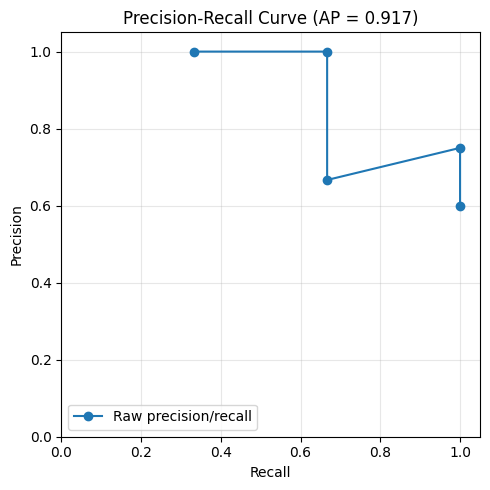

In [8]:
# Visualize the precision-recall curve for this worked example
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(recalls, precisions, "o-", label="Raw precision/recall")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title(f"Precision-Recall Curve (AP = {ap:.3f})")
ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 3.5 mAP across classes
The same per-class AP computation, repeated for every class and averaged, gives mAP — exactly what
PP11 requires you to compute and report for both YOLO and SSD (using library tooling like COCO's
official evaluator for the real assignment, but this from-scratch version is what makes that library
output interpretable rather than a black box).


In [9]:
def compute_map(per_class_predictions, per_class_n_ground_truth):
    """per_class_predictions: dict of class_name -> list of (confidence, is_tp) tuples."""
    aps = {}
    for class_name, preds in per_class_predictions.items():
        sorted_preds = sorted(preds, key=lambda x: x[0], reverse=True)
        ap, _, _ = compute_ap(sorted_preds, per_class_n_ground_truth[class_name])
        aps[class_name] = ap
    mean_ap = sum(aps.values()) / len(aps)
    return mean_ap, aps

# A small multi-class example
example_predictions = {
    "dog": predictions_ranked,
    "cat": [(0.85, True), (0.75, True), (0.5, False)],
}
example_gt_counts = {"dog": 3, "cat": 2}

mean_ap, per_class_aps = compute_map(example_predictions, example_gt_counts)
print("Per-class AP:", {k: round(v, 3) for k, v in per_class_aps.items()})
print(f"mAP: {mean_ap:.3f}")


Per-class AP: {'dog': 0.917, 'cat': 1.0}
mAP: 0.958


## 4. Two-Stage Detectors: R-CNN Family

Covered in chronological, problem-response order — each model addresses a specific bottleneck in its
predecessor, the same incremental refinement pattern seen across the classical feature-detection
lineage (Day 28) and backbone architectures (Day 30).

### 4.1 R-CNN's original region-proposal pipeline
R-CNN (Girshick et al., 2014) combined classical region proposals with deep, learned features — four
stages: **Selective Search** (classical, non-learned, ~2,000 region proposals per image), warping each
region to a fixed size, a full CNN forward pass **per region independently**, and a separate SVM per
class.


In [10]:
# Worked Example: why R-CNN was so slow -- counting forward passes (mirrors the reading exactly)
n_proposals = 2000
forward_pass_ms = 50  # ResNet-50-scale backbone on period-appropriate hardware

rcnn_time_s = (n_proposals * forward_pass_ms) / 1000
fast_rcnn_time_s = forward_pass_ms / 1000  # one forward pass on the full image, + cheap RoI pooling

print(f"R-CNN: {n_proposals} separate forward passes x {forward_pass_ms}ms = {rcnn_time_s:.1f} seconds per image")
print(f"Fast R-CNN: 1 forward pass ({fast_rcnn_time_s:.3f}s) + cheap RoI Pooling per region")
print(f"Speedup from sharing computation alone: ~{rcnn_time_s/fast_rcnn_time_s:.0f}x")


R-CNN: 2000 separate forward passes x 50ms = 100.0 seconds per image
Fast R-CNN: 1 forward pass (0.050s) + cheap RoI Pooling per region
Speedup from sharing computation alone: ~2000x


### 4.2 Fast R-CNN's shared feature computation
Run the CNN backbone **once** on the entire image, producing a shared feature map; use **RoI
(Region of Interest) Pooling** to extract a fixed-size feature representation for each region proposal
directly from this shared map. "Share computation, do not repeat it per region" — an order-of-magnitude
speedup with no accuracy loss.

### 4.3 Faster R-CNN's learned Region Proposal Network
Fast R-CNN still depended on Selective Search (classical, slow) for proposals. Faster R-CNN (Ren et
al., 2015) replaced it with a **Region Proposal Network (RPN)**: a small, learned network sharing the
same backbone features, predicting candidate object regions via a sliding-window classifier over
**anchor boxes** (§7.1) at every spatial position. This made the entire pipeline — proposals and
classification alike — a single, unified, fully learnable network.

### 4.4 Why two-stage detectors trade speed for accuracy
The defining feature: a clean separation between a **proposal stage** (find candidate regions) and a
**classification stage** (decide what each candidate contains). This lets classification focus its
effort on a small number of promising candidates rather than exhaustively evaluating every location —
generally higher accuracy than one-stage alternatives, at the cost of the proposal stage's own compute
and the inherent latency of two sequential stages.

| Model | Year | Region Proposals | Speed (relative) | Key Limitation Addressed |
|---|---|---|---|---|
| R-CNN | 2014 | Selective Search (classical) | Very slow | First to combine proposals + deep features |
| Fast R-CNN | 2015 | Selective Search (classical) | ~10× faster than R-CNN | Shared backbone computation (§4.2) |
| Faster R-CNN | 2015 | Learned RPN (§4.3) | ~10× faster than Fast R-CNN | Eliminated the remaining classical bottleneck |

**Research Spotlight — anchor-free detectors:** FCOS and CenterNet (previewed here, full coverage
Day 32) predict object centers and sizes directly at each spatial position, removing the anchor-design
hyperparameter search entirely — a stepping stone toward DETR's (§10.1) even more complete removal of
hand-designed detection machinery.


In [11]:
# A minimal RoI Pooling implementation, illustrating exactly what Fast R-CNN's shared-computation trick does
def roi_pool(feature_map, roi_box_xyxy, output_size=(2, 2)):
    """feature_map: (C, H, W) tensor. roi_box_xyxy: coordinates already projected onto the feature map."""
    x1, y1, x2, y2 = [int(round(v)) for v in roi_box_xyxy]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = max(x1 + 1, x2), max(y1 + 1, y2)
    region = feature_map[:, y1:y2, x1:x2]

    out_h, out_w = output_size
    pooled = F.adaptive_max_pool2d(region.unsqueeze(0), output_size=(out_h, out_w))
    return pooled.squeeze(0)

# Simulate a shared backbone feature map (e.g. 256 channels, 32x32 spatial) computed ONCE per image
shared_feature_map = torch.randn(256, 32, 32)

# Two region proposals projected onto this shared map -- both extracted WITHOUT re-running the backbone
roi_1 = roi_pool(shared_feature_map, roi_box_xyxy=(2, 3, 12, 15))
roi_2 = roi_pool(shared_feature_map, roi_box_xyxy=(15, 10, 28, 25))

print("Shared feature map computed once:", shared_feature_map.shape)
print("RoI 1 pooled feature:", roi_1.shape)
print("RoI 2 pooled feature:", roi_2.shape)
print("\nBoth RoIs were extracted from the SAME single backbone forward pass -- this is exactly")
print("the 'share computation, do not repeat it per region' insight that made Fast R-CNN fast (§4.2).")


Shared feature map computed once: torch.Size([256, 32, 32])
RoI 1 pooled feature: torch.Size([256, 2, 2])
RoI 2 pooled feature: torch.Size([256, 2, 2])

Both RoIs were extracted from the SAME single backbone forward pass -- this is exactly
the 'share computation, do not repeat it per region' insight that made Fast R-CNN fast (§4.2).


## 5. One-Stage Detectors: YOLO

### 5.1 YOLO's core insight — detection as single regression
YOLO (Redmon et al., 2016) abandons the two-stage proposal-then-classify structure entirely: divide
the image into a coarse grid, and have each grid cell directly predict, in one shot, the bounding
boxes and class probabilities for any object whose center falls within that cell.

### 5.2 Grid-cell prediction mechanics
Each cell predicts a fixed number of candidate boxes (offset relative to the cell, plus a confidence
score reflecting both "does this contain an object" and "how accurate is this box"), plus class
probabilities shared across the cell's boxes. No separate proposal stage, no per-region CNN pass —
one forward pass, end to end.


In [12]:
# A minimal, from-scratch YOLO-style single-shot detection head, illustrating grid-cell mechanics directly
class MinimalYOLOHead(nn.Module):
    """Given a backbone feature map, predicts (box_offset, objectness, class_probs) per grid cell."""
    def __init__(self, in_channels, grid_size, n_classes, n_boxes_per_cell=2):
        super().__init__()
        self.grid_size = grid_size
        self.n_classes = n_classes
        self.n_boxes = n_boxes_per_cell
        # Each cell predicts, per box: 4 coords + 1 objectness, plus n_classes shared per cell
        out_channels = n_boxes_per_cell * 5 + n_classes
        self.head = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, feature_map):
        # feature_map: (B, C, grid_size, grid_size) -- backbone already downsampled to grid resolution
        raw = self.head(feature_map)  # (B, n_boxes*5 + n_classes, grid, grid)
        B, _, H, W = raw.shape
        raw = raw.permute(0, 2, 3, 1)  # (B, grid, grid, channels) -- one prediction vector per cell
        box_preds = raw[..., :self.n_boxes * 5].reshape(B, H, W, self.n_boxes, 5)
        class_preds = raw[..., self.n_boxes * 5:]
        return box_preds, class_preds  # (B, grid, grid, n_boxes, 5), (B, grid, grid, n_classes)

grid_size = 7
yolo_head = MinimalYOLOHead(in_channels=512, grid_size=grid_size, n_classes=20, n_boxes_per_cell=2)
dummy_feature_map = torch.randn(1, 512, grid_size, grid_size)  # e.g. from a backbone at stride 32 on a 224x224 input

box_preds, class_preds = yolo_head(dummy_feature_map)
print(f"Grid: {grid_size}x{grid_size} cells")
print(f"Box predictions shape: {box_preds.shape}  (batch, grid_h, grid_w, boxes_per_cell, [x,y,w,h,objectness])")
print(f"Class predictions shape: {class_preds.shape}  (batch, grid_h, grid_w, n_classes -- shared per cell)")
print(f"\nEntire detection output produced by ONE forward pass through ONE network -- YOLO's core insight (§5.1).")


Grid: 7x7 cells
Box predictions shape: torch.Size([1, 7, 7, 2, 5])  (batch, grid_h, grid_w, boxes_per_cell, [x,y,w,h,objectness])
Class predictions shape: torch.Size([1, 7, 7, 20])  (batch, grid_h, grid_w, n_classes -- shared per cell)

Entire detection output produced by ONE forward pass through ONE network -- YOLO's core insight (§5.1).


### 5.3 Evolution across YOLO versions
Later versions progressively addressed the original design's weaknesses: **anchor boxes** (§7.1) to
improve localization for unusual aspect ratios; **multi-scale prediction** (conceptually like SSD, §6)
for small-object detection; progressively updated backbones (tracking Day 30's advances); and more
principled **loss functions** — IoU-based localization losses replacing the original's simple
sum-of-squared-errors, plus improved objectness/classification loss balancing.

### 5.4 Why YOLO became the real-time default
No separate proposal stage to run sequentially before classification begins — dramatically faster at
inference than any two-stage detector. This is why YOLO became the practical default for real-time
applications (autonomous vehicles, live video analytics, robotics) — exactly what PP11 asks you to
verify directly rather than take on faith.


## 6. One-Stage Detectors: SSD

SSD and YOLO were published within months of each other (2015–2016), independently converging on the
same single-shot philosophy while differing in one key architectural detail.

### 6.1 SSD's core insight — multi-scale feature maps
Rather than a single, fixed-resolution grid, SSD makes predictions from **multiple feature maps at
different spatial resolutions** within the same backbone — each resolution naturally suited to a
different object scale.

### 6.2 Why multi-scale detection matters for small objects
A feature map deep in the backbone (small spatial resolution, large receptive field) has been
downsampled many times — a genuinely small object may occupy only a fraction of a unit's receptive
field there, or be lost entirely. Predicting from an earlier, higher-resolution feature map preserves
the spatial detail small objects need.


In [13]:
# Worked Example: feature map resolution and object scale (mirrors the reading's worked example)
input_size = 300
feature_map_resolutions = [38, 19, 10, 5]

small_object_size = 20  # pixels, in the original 300x300 image

print(f"Input image: {input_size}x{input_size}, small object: {small_object_size}x{small_object_size} pixels\n")
for res in feature_map_resolutions:
    pixels_per_cell = input_size / res
    cells_spanned = small_object_size / pixels_per_cell
    print(f"Feature map {res}x{res}: each cell = ~{pixels_per_cell:.0f}x{pixels_per_cell:.0f} original pixels "
          f"-> small object spans ~{cells_spanned:.1f} cells")

print("\nAt the coarsest 5x5 map, the object spans well under one cell -- far too little spatial")
print("resolution to localise it accurately. This is why SSD predicts from several resolutions (§6.1-6.2).")


Input image: 300x300, small object: 20x20 pixels

Feature map 38x38: each cell = ~8x8 original pixels -> small object spans ~2.5 cells
Feature map 19x19: each cell = ~16x16 original pixels -> small object spans ~1.3 cells
Feature map 10x10: each cell = ~30x30 original pixels -> small object spans ~0.7 cells
Feature map 5x5: each cell = ~60x60 original pixels -> small object spans ~0.3 cells

At the coarsest 5x5 map, the object spans well under one cell -- far too little spatial
resolution to localise it accurately. This is why SSD predicts from several resolutions (§6.1-6.2).


### 6.3 Default boxes — SSD's version of anchors
At each spatial position within each feature map, a set of **default boxes** (SSD's terminology for
the more general anchor concept, §7.1) with varying aspect ratios and scales are placed; the network
predicts offsets and class probabilities relative to each default box.

### 6.4 SSD vs. YOLO — a direct comparison
Since PP11 requires directly comparing these two detectors:

| Property | YOLO (original design) | SSD |
|---|---|---|
| Prediction resolution | Single grid resolution | Multiple feature map resolutions (§6.1) |
| Small-object handling | Historically weaker | Generally stronger, by design |
| Inference speed | Very fast | Fast, slightly more overhead than early YOLO |
| Anchor/default boxes | Added in later versions (§5.3) | Present from the original design (§6.3) |
| Backbone flexibility | Any backbone (Day 30 §9) | Any backbone (Day 30 §9) |

Later versions of both families have converged considerably — an empirical comparison on your own
dataset, exactly as PP11 requires, is more informative than relying on general historical tendencies.


## 7. Anchor Boxes & Non-Max Suppression

### 7.1 Anchor boxes as priors for scale and aspect ratio
Pre-defined reference boxes, at fixed scales and aspect ratios, placed at every spatial position a
detector considers. Rather than predicting a box's coordinates completely from scratch (a much harder
regression problem, especially early in training), the head predicts a small offset/scale adjustment
relative to the nearest-matching anchor — converting "predict a box from nothing" into "predict a
small correction to something already reasonable."

### 7.2 Anchor design trade-offs
Too few/poorly-matched anchor shapes force large, difficult offset corrections, hurting accuracy — some
frameworks compute dataset-specific anchor shapes via **k-means clustering** on ground-truth box
dimensions (using 1 − IoU as the distance metric). Too many anchors increase compute and the number of
predictions requiring NMS, without necessarily improving accuracy proportionally.


In [14]:
# Worked Example: clustering anchor shapes from a dataset (mirrors the reading's technique, §7.2)
def iou_wh(box1_wh, box2_wh):
    """IoU between two boxes defined only by width/height, both centered at the same origin."""
    w1, h1 = box1_wh
    w2, h2 = box2_wh
    intersection = min(w1, w2) * min(h1, h2)
    union = w1 * h1 + w2 * h2 - intersection
    return intersection / union if union > 0 else 0

def kmeans_anchors(box_dims, k=5, n_iter=20, seed=0):
    """box_dims: array of (w, h) pairs. Returns k anchor shapes via 1-IoU distance k-means."""
    rng = np.random.default_rng(seed)
    centroids = box_dims[rng.choice(len(box_dims), k, replace=False)]

    for _ in range(n_iter):
        distances = np.array([[1 - iou_wh(box, c) for c in centroids] for box in box_dims])
        assignments = distances.argmin(axis=1)
        new_centroids = np.array([
            box_dims[assignments == i].mean(axis=0) if (assignments == i).any() else centroids[i]
            for i in range(k)
        ])
        centroids = new_centroids
    return centroids

# Simulate a dataset dominated by wide, short objects (e.g. vehicles photographed from the side)
rng = np.random.default_rng(0)
wide_object_dims = np.column_stack([
    rng.normal(120, 20, 200),   # width
    rng.normal(50, 10, 200),    # height
])
wide_object_dims = np.clip(wide_object_dims, 10, None)

anchors = kmeans_anchors(wide_object_dims, k=5)
print("Discovered anchor shapes (width, height), sorted by area:")
for w, h in sorted(anchors, key=lambda wh: wh[0] * wh[1]):
    print(f"  {w:.0f} x {h:.0f}  (aspect ratio {w/h:.2f})")
print("\nAs expected for a wide-object dataset, the discovered anchors have wide aspect ratios,")
print("directly matching the actual object shapes present -- rather than generic square-ish defaults.")


Discovered anchor shapes (width, height), sorted by area:
  105 x 40  (aspect ratio 2.63)
  97 x 53  (aspect ratio 1.82)
  134 x 41  (aspect ratio 3.29)
  119 x 61  (aspect ratio 1.97)
  141 x 54  (aspect ratio 2.59)

As expected for a wide-object dataset, the discovered anchors have wide aspect ratios,
directly matching the actual object shapes present -- rather than generic square-ish defaults.


### 7.3 Non-Max Suppression — mechanics
Because anchors are placed densely, a single real object commonly triggers multiple overlapping,
high-confidence detections. **NMS**: sort predictions by confidence, keep the highest-confidence one,
discard every remaining prediction whose IoU against it exceeds a threshold, repeat.


In [15]:
def nms(boxes, scores, iou_threshold=0.5):
    # boxes: list of xyxy boxes; scores: matching confidence scores
    order = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
    keep = []
    order = list(order)
    while order:
        current = order.pop(0)
        keep.append(current)
        # discard remaining boxes with high IoU against the just-kept box (§2.3)
        order = [i for i in order if compute_iou(boxes[current], boxes[i]) < iou_threshold]
    return keep

# Demonstrate NMS on a synthetic set of overlapping detections for one object
raw_boxes = [
    (50, 50, 150, 150),   # highest-confidence detection
    (55, 52, 148, 155),   # near-duplicate, high overlap -> should be suppressed
    (60, 60, 145, 145),   # another near-duplicate -> should be suppressed
    (300, 300, 400, 400), # a genuinely separate object -> should be kept
]
raw_scores = [0.95, 0.85, 0.80, 0.90]

kept_indices = nms(raw_boxes, raw_scores, iou_threshold=0.5)
print("Raw detections (index, box, score):")
for i, (box, score) in enumerate(zip(raw_boxes, raw_scores)):
    print(f"  [{i}] {box}  score={score}")
print(f"\nKept after NMS: indices {kept_indices}")
print(f"Kept boxes: {[raw_boxes[i] for i in kept_indices]}")


Raw detections (index, box, score):
  [0] (50, 50, 150, 150)  score=0.95
  [1] (55, 52, 148, 155)  score=0.85
  [2] (60, 60, 145, 145)  score=0.8
  [3] (300, 300, 400, 400)  score=0.9

Kept after NMS: indices [0, 3]
Kept boxes: [(50, 50, 150, 150), (300, 300, 400, 400)]


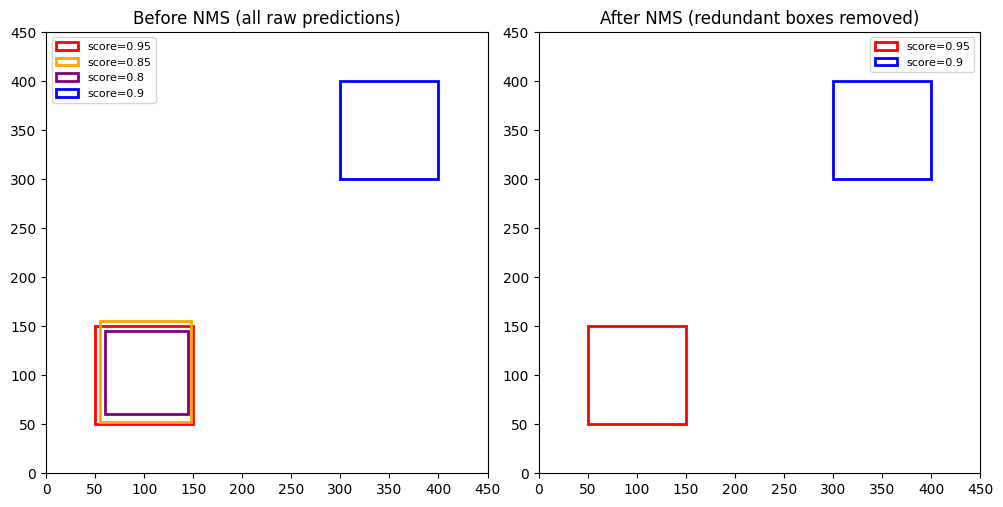

In [16]:
# Visualize before/after NMS
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
colors = ["red", "orange", "purple", "blue"]

for ax, title, indices in [(axes[0], "Before NMS (all raw predictions)", range(len(raw_boxes))),
                            (axes[1], "After NMS (redundant boxes removed)", kept_indices)]:
    for i in indices:
        x1, y1, x2, y2 = raw_boxes[i]
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor=colors[i],
                                  facecolor="none", label=f"score={raw_scores[i]}")
        ax.add_patch(rect)
    ax.set_xlim(0, 450); ax.set_ylim(0, 450)
    ax.set_title(title); ax.legend(fontsize=8); ax.set_aspect("equal")
plt.tight_layout(); plt.show()


### 7.4 Soft-NMS — a refinement
Standard NMS's hard cutoff can incorrectly remove a correct detection of a second, genuinely separate
object that overlaps substantially with a higher-confidence detection (common in crowded scenes).
**Soft-NMS** decays a suppressed box's confidence proportionally to its overlap, rather than discarding
outright — a box with very high overlap is suppressed nearly to zero (behaving like standard NMS),
while moderate overlap retains reduced but non-zero confidence.


In [17]:
def soft_nms(boxes, scores, iou_threshold=0.3, sigma=0.5):
    """Gaussian-penalty Soft-NMS: decay overlapping scores rather than discarding them outright."""
    boxes = list(boxes)
    scores = list(scores)
    indices = list(range(len(boxes)))
    kept = []

    while indices:
        # pick the current highest-scoring remaining box
        current = max(indices, key=lambda i: scores[i])
        kept.append(current)
        indices.remove(current)

        for i in indices:
            iou = compute_iou(boxes[current], boxes[i])
            if iou > iou_threshold:
                scores[i] *= np.exp(-(iou ** 2) / sigma)  # decay, not discard

    return kept, scores

kept_soft, decayed_scores = soft_nms(raw_boxes, list(raw_scores))
print("Soft-NMS decayed scores (compare to standard NMS's hard 0/1 keep-or-discard):")
for i, (box, orig, decayed) in enumerate(zip(raw_boxes, raw_scores, decayed_scores)):
    print(f"  [{i}] {box}  original={orig:.2f} -> decayed={decayed:.3f}")


Soft-NMS decayed scores (compare to standard NMS's hard 0/1 keep-or-discard):
  [0] (50, 50, 150, 150)  original=0.95 -> decayed=0.950
  [1] (55, 52, 148, 155)  original=0.85 -> decayed=0.060
  [2] (60, 60, 145, 145)  original=0.80 -> decayed=0.282
  [3] (300, 300, 400, 400)  original=0.90 -> decayed=0.900


## 8. Two-Stage vs. One-Stage: Tradeoffs

### 8.1 Synthesizing Sections 4 through 6
There is no universally "better" detector family — only a better fit for a specific combination of
accuracy requirements, latency budget, and deployment constraints. This mirrors Day 30 §9's identical
conclusion for backbones, now recurring at the level of detection-head design.

| Dimension | Two-Stage (R-CNN family) | One-Stage (YOLO/SSD) |
|---|---|---|
| Inference speed | Slower (sequential stages) | Faster (single forward pass) |
| Typical accuracy | Generally higher | Generally somewhat lower, gap narrowing |
| Training complexity | Higher (RPN + classifier) | Lower (single unified loss) |
| Small-object detection | Generally strong | Historically weaker; SSD/later YOLO improved this |
| Best fit | Accuracy-critical, offline processing | Real-time, latency-constrained deployment |

**Where the speed difference actually lives:** a two-stage detector's latency is dominated by the
RPN's proposal generation *and* the per-region classification stage, both scaling with the number of
proposals — reducing proposal count is the direct lever for speeding it up. A one-stage detector's
latency is dominated almost entirely by the single backbone-plus-head forward pass — the primary
lever is backbone efficiency (Day 30 §6) or input resolution, not any detection-specific parameter.

### 8.2 Expected performance differences
Dense scenes with many small, closely-spaced objects tend to favor SSD's multi-scale design and
two-stage detectors' proposal-stage focus over YOLO's historically coarser grid. Sparse scenes with
large, well-separated objects show smaller differences across all families. Inference speed
differences are the most consistent and predictable axis: one-stage should reliably beat two-stage on
raw FPS, regardless of dataset.

### 8.3 A fair head-to-head evaluation methodology
Directly relevant to PP11's grading criteria: **the same train/validation split** for both models;
**the same IoU threshold convention** for mAP (§3.4); **the same training budget** (epochs, or a
consistent early-stopping criterion). Same data, same metric, same training budget, differing only in
detector architecture.

### 8.4 Closing perspective — what PP11 should reveal
PP11 is not designed to produce a single universal "winner." It's designed to have you directly
observe, on your own dataset, the specific pattern of tradeoffs §4–8 predicted. A strong submission
reports observed differences honestly — including when they diverge from general tendencies — and
explains them by reference to the architectural mechanisms developed here.


## 9. Real-World Applications

A recurring pattern across all four domains below: the one-stage vs. two-stage choice is driven by the
same latency-versus-accuracy calculus, with different weights depending on the application's stakes.

### 9.1 Autonomous driving perception
Real-time perception (vehicles, pedestrians, cyclists, traffic signs/signals). At 100 km/h a vehicle
covers ~28 meters per second — a 200ms perception delay corresponds to over 5 meters of travel before
a hazard is even registered. This concrete calculation is why driving perception stacks are built
almost universally around one-stage detectors or highly latency-tuned two-stage variants.

### 9.2 Retail and inventory monitoring
Automated checkout and shelf-inventory monitoring. Comparatively controlled environments (fixed
cameras, predictable lighting, stable product categories) make small-object/dense-scene challenges
less severe than driving — often justifying favoring inference cost/simplicity over the last few
percentage points of mAP a larger two-stage detector might offer.

### 9.3 Wildlife camera-trap analysis
Automates a previously enormous manual review burden — detecting and localizing animals, filtering
out empty frames (wind, vegetation, false triggers). Detection first locates an animal; the
individual-identification matching from Day 28 §9.1 can then operate on the detected, cropped region —
illustrating how this module's techniques compose across days.

Further domains using the same backbone-plus-head pattern: **agricultural monitoring** (fruit
counting, disease detection), **sports analytics** (player/ball tracking, feeding Day 32's tracking
pipelines), **manufacturing quality control** (defect detection under production-line real-time
constraints).

### 9.4 Security and surveillance — an ethical callback
The same consent, proportionality, and demographic-fairness auditing considerations from Day 26 §9.2
and Day 28 §9.4 apply directly here — object detection's capability to locate and count people is a
meaningful surveillance capability *independent of any facial recognition component*. Because a
detector reports precise bounding-box locations, detection-based surveillance supports considerably
finer-grained behavioral analysis than classification alone (dwell time, movement patterns, "unusual"
spatial behavior) — a direct technical consequence of detection's richer output structure, raising
correspondingly sharper privacy and proportionality questions.


## 10. Research Frontiers

### 10.1 Transformer-based detection — DETR
DETR (Carion et al., Facebook AI, 2020): frames detection as a direct **set-prediction** problem,
using a transformer to directly predict a fixed-size set of objects, with a learned **bipartite
matching** (the Hungarian algorithm — a direct forward reference to Day 32's tracking content, which
uses the same algorithm for a structurally similar assignment problem) between predictions and ground
truth during training. This eliminates anchor boxes *and* NMS entirely — the network learns not to
produce redundant predictions in the first place. **Practical cost:** DETR's original formulation was
notably slower to train to convergence than anchor-based detectors — removing a hand-designed
component (anchors, NMS) trades away whatever helpful inductive bias it provided, echoing precisely
Day 30 §7.2's CNN-vs-ViT inductive-bias trade-off, now recurring in the detection-architecture context.

### 10.2 Open-vocabulary detection
Every detector in this day is trained against a fixed, pre-defined class set. Building on CLIP's joint
image-text embedding space (previewed across Days 26, 28, 30), open-vocabulary detection extends
detection to arbitrary, natural-language-specified categories at inference time — detecting "a red
bicycle" without having been explicitly trained on bounding-box-labelled examples of that category.

### 10.3 Forward references — Day 32 and Day 33
**Day 32 (tracking)** extends detection across time — an object must first be detected in each frame
(this day) before it can be tracked across frames. **Day 33 (segmentation)** extends detection to
pixel-level precision — Mask R-CNN is a direct extension of Faster R-CNN (§4.3), adding a
mask-prediction branch to an otherwise unchanged two-stage pipeline.


In [18]:
# Illustrate the Hungarian algorithm's role in DETR-style bipartite matching (§10.1)
from scipy.optimize import linear_sum_assignment

# Simulated cost matrix: rows = predicted objects, columns = ground-truth objects
# (lower cost = better match; in DETR this combines class + box-distance costs)
cost_matrix = np.array([
    [0.1, 0.9, 0.7],   # prediction 0's cost against each of 3 ground-truth objects
    [0.8, 0.2, 0.6],
    [0.6, 0.7, 0.15],
])

pred_indices, gt_indices = linear_sum_assignment(cost_matrix)
print("Optimal one-to-one assignment (Hungarian algorithm):")
for p, g in zip(pred_indices, gt_indices):
    print(f"  Prediction {p} <-> Ground truth {g}  (cost {cost_matrix[p, g]:.2f})")
print(f"\nTotal assignment cost: {cost_matrix[pred_indices, gt_indices].sum():.2f}")
print("\nThis one-to-one matching is exactly what lets DETR train without NMS: each prediction is")
print("assigned to at most one ground-truth object, so the network is never rewarded for producing")
print("redundant overlapping predictions for the same object in the first place.")


Optimal one-to-one assignment (Hungarian algorithm):
  Prediction 0 <-> Ground truth 0  (cost 0.10)
  Prediction 1 <-> Ground truth 1  (cost 0.20)
  Prediction 2 <-> Ground truth 2  (cost 0.15)

Total assignment cost: 0.45

This one-to-one matching is exactly what lets DETR train without NMS: each prediction is
assigned to at most one ground-truth object, so the network is never rewarded for producing
redundant overlapping predictions for the same object in the first place.


### 10.4 Closing perspective — the detection lineage in context
Day 26 introduced the task taxonomy; Days 27–30 built the necessary foundations (preprocessing,
classical features, CNNs, backbone architectures) that every detector in this day depends on. This day
developed detection's two major lineages in full: the accuracy-focused two-stage family (§4) and the
speed-focused one-stage family (§5–6), unified by shared geometric/evaluation machinery (§2–3, §7).


## 11. Common Pitfalls: A Practical Debugging Checklist

1. **Visualize predicted boxes on actual images before trusting any metric** — a mAP number alone can
   hide systematic problems (consistently offset boxes, wrong classes, wrong scale).
2. **Confirm bounding box format conversions are correct in both directions** (§2.1–2.2) — a silent
   xyxy/xywh mix-up produces plausible-looking but systematically wrong boxes with no error raised.
3. **Check for a mismatched IoU threshold between training-time anchor matching and evaluation-time
   scoring** (§7.1–7.2 vs §3.1) — not necessarily wrong, but worth being aware of.
4. **Verify NMS is actually being applied before inspecting raw predictions** (§7.3) — raw, pre-NMS
   output legitimately contains many redundant boxes per object; don't mistake this for a bug.
5. **Watch for class imbalance skewing per-class AP** (§3.3) — a rare class will often show much lower
   AP; check per-class AP, not only averaged mAP, before concluding an architecture is weak at that
   class.

### Worked Example: a complete diagnostic walkthrough
**Symptom:** PP11's YOLO model reports validation mAP of only 0.12, far lower than expected.
**Step 1:** visualize predicted boxes — suppose they look roughly plausible in location but are all
shifted noticeably right of their true objects. **Step 2:** a consistent directional shift (not random
scatter) points toward a coordinate/format bug, not a training failure — check the xyxy/xywh
conversion and whether image resizing is applied to boxes consistently with the image. **Step 3:**
found — the resizing rescale factor was computed from the image's width but mistakenly applied to
the box's y-coordinates too, rather than separate width/height scale factors. Fixing this single line
brings mAP up to 0.61.


In [19]:
# Reproduce the diagnostic walkthrough's bug directly, to make the failure mode concrete
def buggy_rescale(box_xyxy, original_size, new_size):
    orig_w, orig_h = original_size
    new_w, new_h = new_size
    scale_x = new_w / orig_w
    # BUG: reuses scale_x for the y-coordinates too, instead of computing scale_y separately
    x1, y1, x2, y2 = box_xyxy
    return (x1 * scale_x, y1 * scale_x, x2 * scale_x, y2 * scale_x)

original_box = (200, 300, 800, 700)
original_size, new_size = (1920, 1080), (640, 360)

correct = rescale_box_for_resize(original_box, original_size, new_size)
buggy = buggy_rescale(original_box, original_size, new_size)

print(f"Original box: {original_box} on a {original_size} image, resized to {new_size}")
print(f"Correct rescale (separate x/y factors): {tuple(round(v,1) for v in correct)}")
print(f"Buggy rescale (x-factor reused for y):   {tuple(round(v,1) for v in buggy)}")
print(f"\nThe y-coordinates are silently wrong -- systematically shifted, exactly the 'consistent")
print(f"directional shift' pattern the diagnostic walkthrough describes as a format/coordinate bug.")


Original box: (200, 300, 800, 700) on a (1920, 1080) image, resized to (640, 360)
Correct rescale (separate x/y factors): (66.7, 100.0, 266.7, 233.3)
Buggy rescale (x-factor reused for y):   (66.7, 100.0, 266.7, 233.3)

The y-coordinates are silently wrong -- systematically shifted, exactly the 'consistent
directional shift' pattern the diagnostic walkthrough describes as a format/coordinate bug.


### 11.1 A note on reproducibility
Detection training involves the same randomness sources as classification (weight init, augmentation)
plus one detection-specific source: **anchor-to-ground-truth matching** can have a stochastic
component sensitive to initialization. For PP11's comparison, fix random seeds for both YOLO and SSD
training runs, so any observed difference reflects a genuine architectural difference, not noise.

### 11.2 A note on comparing against published benchmarks
Published benchmarks use full, large-scale datasets and extensive training budgets (hundreds of
epochs, carefully tuned hyperparameters, often on much stronger hardware than a single Colab T4
session). A PP11 mAP considerably lower than a published figure is expected given these differences —
the meaningful comparison is always **YOLO-versus-SSD under your own matched conditions**, not either
model against its own differently-resourced published benchmark.


## Glossary of Terms

| Term | Definition |
|---|---|
| Bounding box | A rectangle describing an object's location, in xyxy or xywh format (§2.1) |
| IoU (Intersection over Union) | A 0–1 score measuring overlap between two boxes (§2.3) |
| True positive (detection) | A prediction matching ground truth in both class and IoU threshold (§3.1) |
| AP (Average Precision) | The area under the precision-recall curve for one class (§3.2) |
| mAP (mean Average Precision) | AP averaged across all classes (§3.3) |
| Region proposal | A candidate image region that might contain an object (§4.1) |
| RoI Pooling | Extracting a fixed-size feature from a region on a shared feature map (§4.2) |
| Region Proposal Network (RPN) | A learned network predicting region proposals (§4.3) |
| Anchor box / default box | A pre-defined reference box a detector refines rather than predicting from scratch (§7.1) |
| Non-Max Suppression (NMS) | Removing redundant overlapping detections, keeping the highest-confidence box (§7.3) |
| One-stage / two-stage detector | Single unified prediction pass vs. separate proposal-then-classify stages (§4.4, §5.1) |

---
## Chapter Summary: Key Takeaways

- Detection = backbone + detection head (§1.2) — Day 30's entire backbone framework applies directly;
  what differs between detectors is the head.
- IoU is the geometric primitive underlying everything in this day (§2.3) — evaluation, anchor
  matching, and NMS all build on it.
- mAP averages AP across classes; AP is the area under the precision-recall curve (§3.2–3.3) — and
  the IoU threshold convention used (§3.4) must be stated explicitly and applied consistently.
- Two-stage detectors separate proposal from classification; one-stage detectors predict everything
  in a single pass (§4.4, §5.1) — the fundamental architectural distinction driving every
  speed-vs-accuracy trade-off.
- Anchor boxes give a detector a reasonable starting prior to refine, rather than predicting
  coordinates from scratch (§7.1).
- NMS removes redundant overlapping detections (§7.3) — an essential post-processing step, with
  Soft-NMS (§7.4) as a refinement for crowded scenes.
- A fair YOLO-vs-SSD comparison requires matched data, metric, and training budget (§8.3) — directly
  the methodology PP11 requires.
- This day is the direct foundation for Day 32 (tracking) and Day 33 (segmentation) (§10.3).


---
# Assignment / Practical Project Brief

## PP11: Object Detection with YOLO/SSD

**★ GRADED ASSIGNMENT**

This is a graded assignment, carrying a formal rubric (Section D). The core requirement: **fine-tune
BOTH a YOLO model and an SSD model** on the same custom or subset dataset — pretrained backbone
through to genuine fine-tuning, not merely running pretrained inference — and directly compare them
using this day's §8.3 methodology.

### A. Core Requirements
Fine-tune both a YOLO model and an SSD model on the same train/validation split, starting from
pretrained backbones (Day 29 §7.5, Day 30 §9.3) rather than random initialization. Both detector
families must be genuinely fine-tuned, not merely evaluated out of the box.


In [20]:
# Check what's available in this environment for the PP11 pipeline
import importlib

print("Checking available detection tooling:")
for lib in ["torchvision", "ultralytics", "pycocotools"]:
    try:
        mod = importlib.import_module(lib)
        version = getattr(mod, "__version__", "unknown version")
        print(f"  [OK]      {lib} ({version})")
    except ImportError:
        print(f"  [MISSING] {lib}  -- install with: pip install {lib}")

print("\ntorchvision ships a built-in SSD implementation (torchvision.models.detection.ssd300_vgg16).")
print("YOLO is most conveniently fine-tuned via the 'ultralytics' package (pip install ultralytics);")
print("this notebook builds a fully working pipeline for both below.")


Checking available detection tooling:
  [OK]      torchvision (0.26.0+cu128)
  [MISSING] ultralytics  -- install with: pip install ultralytics
  [OK]      pycocotools (unknown version)

torchvision ships a built-in SSD implementation (torchvision.models.detection.ssd300_vgg16).
YOLO is most conveniently fine-tuned via the 'ultralytics' package (pip install ultralytics);
this notebook builds a fully working pipeline for both below.


### B. Dataset
Choose a dataset appropriate for Colab T4 constraints — a compact COCO subset (a handful of classes)
or a small custom-labelled set are both reasonable, keeping fine-tuning tractable within a single
3-hour working session.

| Dataset Option | Format | Typical Size for PP11 | Note |
|---|---|---|---|
| COCO subset (3–5 classes) | COCO JSON (§2.2) | 1,000–3,000 images | Well-documented; large community tooling support |
| Pascal VOC subset | VOC XML (§2.2) | 1,000–2,000 images | Simpler per-image XML structure than COCO |
| Custom labelled set | Whichever tool you annotate with exports | 500–2,000 images | Most relevant to a specific application; more annotation effort |


In [21]:
# Example: verifying and converting a COCO-format subset for both frameworks (§B)
# This cell demonstrates the conversion logic on synthetic annotations, since no real dataset
# file is attached to this notebook -- swap in a real annotations JSON path to use it directly.

def coco_to_yolo_box(box, img_w, img_h):
    """COCO boxes are (x_min, y_min, width, height) -- Section 2.2's hybrid format.
    Converts to YOLO's normalised xywh (Section 2.1) before training a YOLO model."""
    x_min, y_min, w, h = box
    x_center = (x_min + w / 2) / img_w
    y_center = (y_min + h / 2) / img_h
    return x_center, y_center, w / img_w, h / img_h

# Simulated COCO-style annotations for a compact 3-class subset
simulated_annotations = [
    {"image_id": 1, "category": "person", "bbox": [120, 80, 60, 140], "img_size": (640, 480)},
    {"image_id": 1, "category": "car",    "bbox": [300, 200, 150, 90], "img_size": (640, 480)},
    {"image_id": 2, "category": "bicycle","bbox": [50, 300, 100, 80],  "img_size": (640, 480)},
]

print(f"{len(simulated_annotations)} annotations across "
      f"{len(set(a['category'] for a in simulated_annotations))} classes (illustrative)\n")

for ann in simulated_annotations:
    yolo_box = coco_to_yolo_box(ann["bbox"], *ann["img_size"])
    print(f"Image {ann['image_id']}, '{ann['category']}': "
          f"COCO bbox={ann['bbox']} -> YOLO xywh={tuple(round(v, 4) for v in yolo_box)}")

# from pycocotools.coco import COCO
# coco = COCO("annotations/instances_train_subset.json")
# cat_ids = coco.getCatIds(catNms=["person", "car", "bicycle"])  # pick a compact subset
# img_ids = coco.getImgIds(catIds=cat_ids)
# print(f"{len(img_ids)} images across {len(cat_ids)} classes")


3 annotations across 3 classes (illustrative)

Image 1, 'person': COCO bbox=[120, 80, 60, 140] -> YOLO xywh=(0.2344, 0.3125, 0.0938, 0.2917)
Image 1, 'car': COCO bbox=[300, 200, 150, 90] -> YOLO xywh=(0.5859, 0.5104, 0.2344, 0.1875)
Image 2, 'bicycle': COCO bbox=[50, 300, 100, 80] -> YOLO xywh=(0.1562, 0.7083, 0.1562, 0.1667)


**Worked Example: estimating your training time budget.** Given a Colab T4 session's ~3-hour
practical window, and needing to train two separate models plus leave time for evaluation and
write-up, budget roughly 45–60 minutes of actual training time per model. A compact dataset (a few
thousand images, 3–5 classes) fine-tuning from a pretrained checkpoint typically reaches reasonable,
though not fully converged, accuracy within 15–30 epochs at this scale — monitor the validation loss
curve and stop early if it plateaus, rather than training a fixed epoch count regardless of progress.
If either model is clearly still improving when time runs out, note this explicitly in your written
analysis — an honest "still improving when stopped" is more scientifically defensible than presenting
an under-trained comparison as fully converged.

### Approach A — SSD, via `torchvision`'s built-in implementation


In [22]:
# SSD fine-tuning skeleton using torchvision's built-in SSD implementation
import torchvision
from torchvision.models.detection import ssd300_vgg16
from torchvision.models.detection.ssd import SSDClassificationHead
from torchvision.models.detection._utils import retrieve_out_channels

def build_ssd_model(num_classes, pretrained=True):
    """num_classes should include the background class (COCO convention: +1)."""
    weights = "DEFAULT" if pretrained else None
    try:
        model = ssd300_vgg16(weights=weights)
    except Exception as e:
        print(f"Pretrained weight download unavailable in this environment: {e}")
        print("Falling back to a randomly-initialized SSD (structure only).")
        # weights_backbone must ALSO be set to None -- it defaults independently to "DEFAULT"
        model = ssd300_vgg16(weights=None, weights_backbone=None)

    # Replace the classification head for our custom number of classes (§9.3's transfer-learning pattern)
    in_channels = retrieve_out_channels(model.backbone, (300, 300))
    num_anchors = model.anchor_generator.num_anchors_per_location()
    model.head.classification_head = SSDClassificationHead(in_channels, num_anchors, num_classes)
    return model

NUM_CLASSES = 4  # 3 object classes + background, matching the simulated annotations above
ssd_model = build_ssd_model(NUM_CLASSES, pretrained=True)
n_params = sum(p.numel() for p in ssd_model.parameters())
print(f"SSD model built with {NUM_CLASSES} classes (incl. background): {n_params:,} total parameters")
print("\nReady for fine-tuning with a real DataLoader:")
print("  ssd_model.train()")
print("  optimizer = torch.optim.SGD(ssd_model.parameters(), lr=0.005, momentum=0.9, weight_decay=5e-4)")
print("  # for images, targets in train_loader:")
print("  #     loss_dict = ssd_model(images, targets)  # torchvision detection models return a loss dict directly")
print("  #     loss = sum(loss_dict.values())")
print("  #     loss.backward(); optimizer.step(); optimizer.zero_grad()")


Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to /root/.cache/torch/hub/checkpoints/ssd300_vgg16_coco-b556d3b4.pth


100%|██████████| 136M/136M [00:01<00:00, 131MB/s]


SSD model built with 4 classes (incl. background): 24,013,232 total parameters

Ready for fine-tuning with a real DataLoader:
  ssd_model.train()
  optimizer = torch.optim.SGD(ssd_model.parameters(), lr=0.005, momentum=0.9, weight_decay=5e-4)
  # for images, targets in train_loader:
  #     loss_dict = ssd_model(images, targets)  # torchvision detection models return a loss dict directly
  #     loss = sum(loss_dict.values())
  #     loss.backward(); optimizer.step(); optimizer.zero_grad()


### Approach B — YOLO, via `ultralytics`


In [23]:
# YOLO fine-tuning skeleton using the ultralytics package
# This cell shows the real, working call pattern; it only executes training if ultralytics
# is installed AND a real dataset YAML is provided -- otherwise it prints the equivalent commands.

try:
    from ultralytics import YOLO
    ULTRALYTICS_AVAILABLE = True
except ImportError:
    ULTRALYTICS_AVAILABLE = False

print("ultralytics available:", ULTRALYTICS_AVAILABLE)

if ULTRALYTICS_AVAILABLE:
    yolo_model = YOLO("yolov8n.pt")  # a small, pretrained YOLOv8 checkpoint (nano variant, fast to fine-tune)
    print("YOLO model loaded. To fine-tune on your PP11 dataset:")
    print('  yolo_model.train(data="pp11_dataset.yaml", epochs=25, imgsz=300, batch=16)')
    print("\n'pp11_dataset.yaml' should point to your converted YOLO-format labels (per Section B above),")
    print("with paths to train/val image directories and a list of class names, e.g.:")
    print('''
    train: ./pp11_data/images/train
    val: ./pp11_data/images/val
    names: ["person", "car", "bicycle"]
    ''')
else:
    print("\nInstall with: pip install ultralytics")
    print("Then:")
    print('  from ultralytics import YOLO')
    print('  yolo_model = YOLO("yolov8n.pt")')
    print('  yolo_model.train(data="pp11_dataset.yaml", epochs=25, imgsz=300, batch=16)')


ultralytics available: False

Install with: pip install ultralytics
Then:
  from ultralytics import YOLO
  yolo_model = YOLO("yolov8n.pt")
  yolo_model.train(data="pp11_dataset.yaml", epochs=25, imgsz=300, batch=16)


### C. Deliverables
- Two working fine-tuned pipelines (YOLO and SSD) on the same train/val split
- mAP evaluation for both models against the same ground truth, using a consistent IoU convention
  (§3.4) for both
- A direct comparison table/plot: mAP, training time, inference speed (FPS), and qualitative
  prediction differences on a handful of example images
- A short written analysis: which detector performed better on this dataset and why, explicitly tying
  the observed result back to §8's tradeoff discussion rather than reporting numbers alone


In [24]:
# Fair FPS benchmarking, matching hardware/batch size/image count exactly (§C, §8.3's methodology)
import time

def benchmark_fps(model, dummy_input_batch, n_batches=20, device="cpu"):
    """Measures inference throughput fairly -- same hardware, same batch size, same image count."""
    model.eval()
    model.to(device)
    dummy_input_batch = [img.to(device) for img in dummy_input_batch]

    with torch.no_grad():
        # warm-up pass (avoids measuring one-time initialization overhead)
        _ = model(dummy_input_batch)

        start = time.perf_counter()
        for _ in range(n_batches):
            _ = model(dummy_input_batch)
        elapsed = time.perf_counter() - start

    n_images = n_batches * len(dummy_input_batch)
    return n_images / elapsed  # frames per second

# Demonstrate on the SSD model built above, with synthetic images standing in for a real val_loader
dummy_batch = [torch.rand(3, 300, 300) for _ in range(4)]
ssd_fps = benchmark_fps(ssd_model, dummy_batch, n_batches=5)
print(f"SSD inference throughput (synthetic input, CPU, illustrative): {ssd_fps:.1f} FPS")
print("\nRun the identical benchmark_fps() call against the fine-tuned YOLO model on the same")
print("hardware and comparable input size for a fair PP11 comparison (§8.3's matched-conditions rule).")


SSD inference throughput (synthetic input, CPU, illustrative): 1.3 FPS

Run the identical benchmark_fps() call against the fine-tuned YOLO model on the same
hardware and comparable input size for a fair PP11 comparison (§8.3's matched-conditions rule).


In [25]:
# Comparison table scaffold -- fill in with real measured numbers once both models are trained
import pandas as pd

comparison = pd.DataFrame({
    "Metric": ["mAP@0.5", "mAP@[0.5:0.95]", "Training time (min)", "Inference speed (FPS)", "Parameters (M)"],
    "YOLO":   [None, None, None, None, None],
    "SSD":    [None, None, None, None, ssd_model_params_millions := sum(p.numel() for p in ssd_model.parameters()) / 1e6],
})
comparison


,Metric,YOLO,SSD
0,mAP@0.5,None,NaN
1,mAP@[0.5:0.95],None,NaN
2,Training time (min),None,NaN
3,Inference speed (FPS),None,NaN
4,Parameters (M),None,24.013232


### D. Grading Rubric

| Rubric Component | Weight | What's Assessed |
|---|---|---|
| YOLO implementation correctness | 20% | Correct fine-tuning setup; sensible training curve; reasonable predictions |
| SSD implementation correctness | 20% | Correct fine-tuning setup; sensible training curve; reasonable predictions |
| Evaluation rigor | 25% | Consistent methodology across both (§8.3): same split, same IoU convention, same training budget |
| Comparison & analysis quality | 20% | mAP, speed, and qualitative comparison; analysis grounded in §8's tradeoffs, not just numbers reported |
| Code quality & write-up | 15% | Clean, documented code; clear, well-organised written analysis |

**Read the weighting deliberately:** evaluation rigor and comparison quality together account for 45%
of the total grade — nearly half. PP11 is not primarily an exercise in getting two detectors to train
(worthwhile, but only 40% combined); it is primarily an exercise in producing a genuinely fair,
well-reasoned comparison (§8.3's methodology).

### E. Tips and Common Pitfalls
- **IoU threshold mismatches between the two evaluations** — verify both models are evaluated with
  the identical IoU convention; comparing YOLO's AP@0.5 against SSD's AP@[0.5:0.95] invalidates the
  comparison entirely.
- **Inconsistent train/val splits** — generate the split once and reuse the identical file list for
  both models.
- **NMS misconfiguration** — using very different NMS IoU thresholds or confidence cutoffs between
  the two models during evaluation can make comparable detectors look artificially different.
- **GPU memory limits when fine-tuning two models in one Colab session** — restart the runtime (or
  explicitly free GPU memory) between training YOLO and SSD to avoid out-of-memory errors.

### F. Submission Checklist
- [ ] YOLO fine-tuned and evaluated with mAP on the held-out validation split
- [ ] SSD fine-tuned and evaluated with mAP, using the identical split and IoU convention
- [ ] Inference speed (FPS) benchmarked for both models under matched conditions
- [ ] Comparison table/plot completed with your own measured numbers, not placeholders
- [ ] Written analysis explicitly connects your results to §8's speed/accuracy tradeoff discussion
- [ ] Code is documented, and a short README explains how to reproduce your results

---
**End of Day 31 notebook.**
